In [7]:
import warnings
warnings.filterwarnings("ignore")
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from sklearn.cluster import HDBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    davies_bouldin_score,
    pairwise_distances_argmin_min,
    silhouette_score,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed, Input
from tensorflow.keras.models import Model

sns.set_theme(style="whitegrid")


os.environ['PYTHONHASHSEDD'] = '42'
random.seed(42)
np.random.seed(42)


In [8]:
# =============================================================================
# 1. Hyperparameters & Configuration
# =============================================================================

TIME_STEPS = 24
ANOMALY_PERCENTILE = 99 
CONSECUTIVE_MINUTES = 5 
FEATURE_TO_PLOT = "aircomp_temp"

# UMAP & HDBSCAN Hyperparameters
UMAP_COMPONENTS = 4
UMAP_N_NEIGHBORS = 100 #30
UMAP_MIN_DIST = 0.2 #0.0
UMAP_METRIC = "cosine"

HDBSCAN_MIN_CLUSTER_SIZE = 100 #125  # Minimum samples to form a stable operating mode
HDBSCAN_MIN_SAMPLES = 20  #25  #10   # Conservatism parameter against transitional noise

In [9]:
# =============================================================================
# 2. Data Loading & Preprocessing
# =============================================================================

df_train = pd.read_parquet("df_train.parquet")
df_train["sys_phase"] = df_train["sys_phase"].astype("category")

df_test = pd.read_parquet("df_test.parquet")
df_test["sys_phase"] = df_test["sys_phase"].astype("category")

categorical_cols = df_train.select_dtypes(include="category").columns.tolist()
numerical_cols = df_train.select_dtypes(include="number").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

processed_train = preprocessor.fit_transform(df_train)
processed_test = preprocessor.transform(df_test)

feature_names = numerical_cols + preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols).tolist()

df_train_scaled = pd.DataFrame(processed_train, index=df_train.index, columns=feature_names)
df_test_scaled = pd.DataFrame(processed_test, index=df_test.index, columns=feature_names)


def create_sequences(df_features: pd.DataFrame, time_steps: int = 24) -> np.ndarray:
    """Transform 2D tabular data into 3D sequences (samples, time_steps, features)."""
    values = df_features.values
    return np.array([values[i : (i + time_steps)] for i in range(len(values) - time_steps)])


X_train = create_sequences(df_train_scaled, TIME_STEPS)
X_test = create_sequences(df_test_scaled, TIME_STEPS)
num_features = X_train.shape[2]

In [10]:
# =============================================================================
# 3. Model Architecture Factory & Helpers
# =============================================================================

def build_lstm_ae(time_steps: int, n_features: int, encoder_name: str = "encoder_lstm") -> Model:
    """Construct an LSTM Autoencoder using the Functional API."""
    inputs = Input(shape=(time_steps, n_features), name="input_layer")
    
    # Encoder
    encoded = LSTM(64, activation="tanh", return_sequences=False, name=encoder_name)(inputs)
    x = Dropout(0.2)(encoded)
    
    # Bridge & Decoder
    x = RepeatVector(time_steps)(x)
    x = LSTM(64, activation="tanh", return_sequences=True, name="decoder_lstm")(x)
    x = Dropout(0.2)(x)
    outputs = TimeDistributed(Dense(n_features), name="output_layer")(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer="adam", loss="mse")
    return model


def filter_sustained_anomalies(anomaly_mask: pd.Series, min_duration: int = 5) -> pd.Series:
    """Filter transient flags; keep only sustained blocks > min_duration minutes."""
    raw_anomalies = anomaly_mask[anomaly_mask].copy()
    if raw_anomalies.empty:
        return pd.Series(False, index=anomaly_mask.index)
    
    is_new_block = raw_anomalies.index.to_series().diff() > pd.Timedelta(minutes=1)
    block_id = is_new_block.cumsum()
    block_durations = block_id.map(block_id.value_counts())
    sustained_indices = raw_anomalies[block_durations > min_duration].index
    
    return anomaly_mask.index.isin(sustained_indices)

In [11]:
# =============================================================================
# 4. Global Baseline LSTM Autoencoder
# =============================================================================

print("\n--- Training Global Baseline LSTM Autoencoder ---")
global_model = build_lstm_ae(TIME_STEPS, num_features)
global_model.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, mode="min", restore_best_weights=True)],
)

# Baseline Evaluation
global_train_mae = np.mean(np.abs(global_model.predict(X_train, verbose=0) - X_train), axis=(1, 2))
global_threshold = np.percentile(global_train_mae, ANOMALY_PERCENTILE)

global_test_mae = np.mean(np.abs(global_model.predict(X_test, verbose=0) - X_test), axis=(1, 2))
baseline_raw_anomaly = global_test_mae > global_threshold



--- Training Global Baseline LSTM Autoencoder ---



--- Extracting Latent Space & Running UMAP + HDBSCAN ---
Discovered 4 Operational Regimes (excluding noise).
Silhouette Score (excl. noise): 0.4447 (higher is better)
Davies-Bouldin Index (excl. noise): 0.8639 (lower is better)
Total Samples: 16986 | Noise Points: 2570 (15.13%)


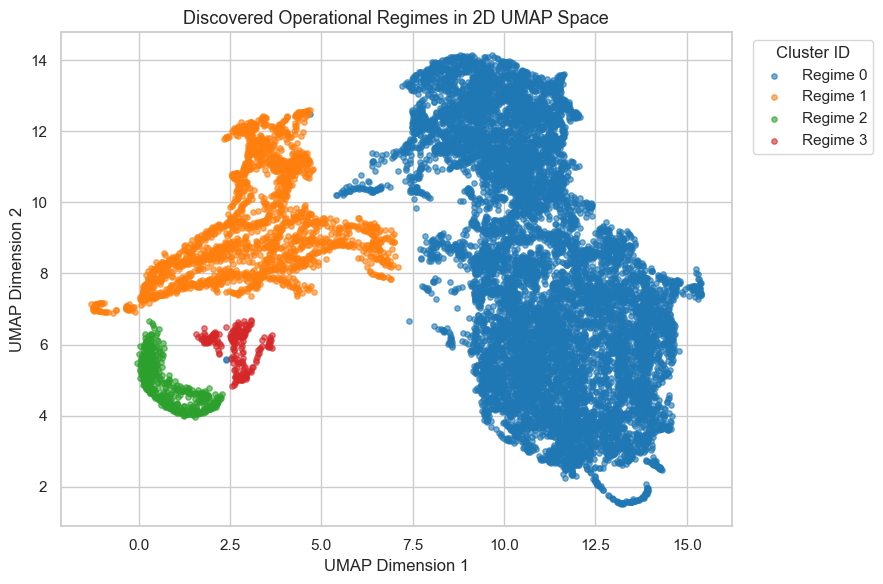


--- Feature Means per Operational Regime ---
         gfd_res  bat_soc  aux_cw_temp  aux_hw_temp  trac_cw_temp  \
Cluster                                                             
0          702.0     62.0         47.0         48.0          48.0   
1          712.0     60.0         41.0         42.0          47.0   
2          721.0     58.0         24.0         24.0          31.0   
3          721.0     61.0         35.0         36.0          44.0   

         trac_hw_temp  aircomp_speed  aircomp_temp  dcdc1_power  
Cluster                                                          
0                48.0          423.0          54.0          3.0  
1                47.0          333.0          47.0          3.0  
2                31.0          275.0          28.0          3.0  
3                44.0          352.0          41.0          3.0  

--- Noise Points Mean (2570 samples) ---
gfd_res          704.0
bat_soc           63.0
aux_cw_temp       45.0
aux_hw_temp       46.0
trac_cw_t

In [12]:
# =============================================================================
# 5. Latent Space Representation & UMAP + HDBSCAN Clustering
# =============================================================================

print("\n--- Extracting Latent Space & Running UMAP + HDBSCAN ---")
encoder_model = Model(inputs=global_model.input, outputs=global_model.get_layer("encoder_lstm").output)
latent_train = encoder_model.predict(X_train, verbose=0)

# Non-linear dimension reduction with UMAP
umap_reducer = umap.UMAP(
    n_components=UMAP_COMPONENTS,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=42,
    n_jobs=1 
)
latent_train_umap = umap_reducer.fit_transform(latent_train)

# Hierarchical density clustering with HDBSCAN
hdbscan_clusterer = HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method="eom",
    n_jobs=1 
)
train_cluster_labels = hdbscan_clusterer.fit_predict(latent_train_umap)

# Clustering Quality Assessment
mask_valid = train_cluster_labels != -1
unique_clusters = [c for c in set(train_cluster_labels) if c != -1]
n_clusters = len(unique_clusters)

print(f"Discovered {n_clusters} Operational Regimes (excluding noise).")
if n_clusters > 1:
    sil_score = silhouette_score(latent_train_umap[mask_valid], train_cluster_labels[mask_valid])
    db_index = davies_bouldin_score(latent_train_umap[mask_valid], train_cluster_labels[mask_valid])
    print(f"Silhouette Score (excl. noise): {sil_score:.4f} (higher is better)")
    print(f"Davies-Bouldin Index (excl. noise): {db_index:.4f} (lower is better)")

noise_count = np.sum(train_cluster_labels == -1)
print(f"Total Samples: {len(train_cluster_labels)} | Noise Points: {noise_count} ({noise_count / len(train_cluster_labels):.2%})")

# Map clusters back to training DataFrame
df_train["Operating_Mode"] = np.nan
df_train.loc[df_train.index[TIME_STEPS:], "Operating_Mode"] = train_cluster_labels

# 2D Visualization of UMAP Manifolds (excluding noise with discrete legend)
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=42
)
latent_2d_viz = umap_2d.fit_transform(latent_train)

# Identify unique non-noise clusters
unique_clusters = sorted([c for c in set(train_cluster_labels) if c != -1])
cmap = plt.get_cmap("tab10")

plt.figure(figsize=(9, 6))

for i, cluster_id in enumerate(unique_clusters):
    mask = train_cluster_labels == cluster_id
    plt.scatter(
        latent_2d_viz[mask, 0],
        latent_2d_viz[mask, 1],
        color=cmap(i % 10),
        label=f"Regime {cluster_id}",
        s=15,
        alpha=0.6
    )

plt.title("Discovered Operational Regimes in 2D UMAP Space", fontsize=13)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(
    title="Cluster ID",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)
plt.tight_layout()
plt.show()


# Operational Sanity Check (Domain Validation)

# Align DataFrame with sequence-trimmed cluster labels

df_analysis = df_train.iloc[TIME_STEPS:].copy()
df_analysis['Cluster'] = train_cluster_labels

# Separate clustered regimes from noise (-1)

valid_clusters = df_analysis[df_analysis['Cluster'] != -1]
noise_points = df_analysis[df_analysis['Cluster'] == -1]

# Feature means across discovered operating regimes

cluster_means = valid_clusters.groupby('Cluster')[numerical_cols].mean()
cluster_stds = valid_clusters.groupby('Cluster')[numerical_cols].std()

print("\n--- Feature Means per Operational Regime ---")

with pd.option_context("display.max_columns", None):
    print(cluster_means.round(0))

if not noise_points.empty:
    print(f"\n--- Noise Points Mean ({len(noise_points)} samples) ---")
    print(noise_points[numerical_cols].mean().round(0))
    
    

print("\n--- Feature SD per Operational Regime ---")

with pd.option_context("display.max_columns", None):
    print(cluster_stds.round(0))

if not noise_points.empty:
    print(f"\n--- Noise Points Std ({len(noise_points)} samples) ---")
    print(noise_points[numerical_cols].std().round(0))


In [13]:
# =============================================================================
# 6. Train Specialized Regime-Specific Models
# =============================================================================

valid_train = df_train[df_train["Operating_Mode"].notna() & (df_train["Operating_Mode"] != -1)]
cluster_dfs = [group for _, group in valid_train.groupby("Operating_Mode")]

regime_models_dict = {}
regime_thresholds_dict = {}

for cluster_df in cluster_dfs:
    cluster_id = int(cluster_df["Operating_Mode"].iloc[0])
    cluster_scaled = df_train_scaled.loc[cluster_df.index]
    X_cluster = create_sequences(cluster_scaled, TIME_STEPS)

    if len(X_cluster) < 15:
        print(f"Skipping Regime {cluster_id}: Insufficient sequences ({len(X_cluster)}).")
        continue

    print(f"Training specialized AE for Regime {cluster_id} ({len(X_cluster)} sequences)...")
    r_model = build_lstm_ae(TIME_STEPS, num_features)
    r_model.fit(
        X_cluster,
        X_cluster,
        epochs=20,
        batch_size=32,
        validation_split=0.1,
        verbose=0,
        callbacks=[EarlyStopping(monitor="val_loss", patience=3, mode="min", restore_best_weights=True)],
    )

    preds_c = r_model.predict(X_cluster, verbose=0)
    mae_c = np.mean(np.abs(preds_c - X_cluster), axis=(1, 2))
    
    regime_models_dict[cluster_id] = r_model
    regime_thresholds_dict[cluster_id] = np.percentile(mae_c, ANOMALY_PERCENTILE)


Training specialized AE for Regime 0 (11375 sequences)...
Training specialized AE for Regime 1 (2247 sequences)...
Training specialized AE for Regime 2 (488 sequences)...
Training specialized AE for Regime 3 (210 sequences)...


In [14]:
# =============================================================================
# 7. Solution 1: Best-Fit Reconstruction Loss (Min-Loss Ensemble)
# =============================================================================

print("\n--- Evaluating Solution 1: Best-Fit Min Reconstruction Loss ---")

all_regime_test_maes = []
for cid, r_model in regime_models_dict.items():
    pred_test = r_model.predict(X_test, verbose=0)
    mae = np.mean(np.abs(pred_test - X_test), axis=(1, 2))
    all_regime_test_maes.append(mae)

min_regime_test_mae = np.min(np.array(all_regime_test_maes), axis=0)
sol1_threshold = np.max(list(regime_thresholds_dict.values()))
sol1_raw_anomaly = min_regime_test_mae > sol1_threshold



--- Evaluating Solution 1: Best-Fit Min Reconstruction Loss ---


In [15]:
# =============================================================================
# 8. Solution 2: Gated Mixture-of-Experts (MoE) via UMAP Routing
# =============================================================================

print("--- Evaluating Solution 2: Gated MoE via Latent Space Routing ---")

# Step 1: Project test sequences into the trained UMAP manifold
latent_test = encoder_model.predict(X_test, verbose=0)
latent_test_umap = umap_reducer.transform(latent_test)

# Step 2: Route test vectors to nearest training cluster centroids
core_features = []
core_labels = []
for cid in regime_models_dict.keys():
    cluster_points = latent_train_umap[train_cluster_labels == cid]
    core_features.append(np.mean(cluster_points, axis=0))
    core_labels.append(cid)

core_features = np.array(core_features)
core_labels = np.array(core_labels)

closest_centroids, distances = pairwise_distances_argmin_min(latent_test_umap, core_features)

# Dynamic distance cutoff based on 95th percentile training dispersion within clusters
intra_cluster_dists = []
for cid in regime_models_dict.keys():
    pts = latent_train_umap[train_cluster_labels == cid]
    centroid = np.mean(pts, axis=0)
    intra_cluster_dists.extend(np.linalg.norm(pts - centroid, axis=1))
max_allowed_dist = np.percentile(intra_cluster_dists, 95)

test_assigned_modes = np.where(distances <= max_allowed_dist, core_labels[closest_centroids], -1)

# Step 3: Evaluate each sample exclusively against its assigned regime model
sol2_raw_anomaly = np.zeros(len(X_test), dtype=bool)

for i, mode in enumerate(test_assigned_modes):
    if mode == -1 or mode not in regime_models_dict:
        # Out-of-distribution in latent manifold
        sol2_raw_anomaly[i] = True
    else:
        sample_seq = X_test[i : i + 1]
        sample_pred = regime_models_dict[mode].predict(sample_seq, verbose=0)
        sample_mae = np.mean(np.abs(sample_pred - sample_seq))
        sol2_raw_anomaly[i] = sample_mae > regime_thresholds_dict[mode]


--- Evaluating Solution 2: Gated MoE via Latent Space Routing ---


In [16]:
# =============================================================================
# 9. Temporal Continuity Filter & Results Consolidation
# =============================================================================

test_timestamps = df_test.index[TIME_STEPS:]
comparison_df = pd.DataFrame(index=test_timestamps)

comparison_df["Baseline_Raw"] = baseline_raw_anomaly
comparison_df["Sol1_MinLoss_Raw"] = sol1_raw_anomaly
comparison_df["Sol2_GatedMoE_Raw"] = sol2_raw_anomaly

comparison_df["Baseline_Sustained"] = filter_sustained_anomalies(comparison_df["Baseline_Raw"], CONSECUTIVE_MINUTES)
comparison_df["Sol1_MinLoss_Sustained"] = filter_sustained_anomalies(comparison_df["Sol1_MinLoss_Raw"], CONSECUTIVE_MINUTES)
comparison_df["Sol2_GatedMoE_Sustained"] = filter_sustained_anomalies(comparison_df["Sol2_GatedMoE_Raw"], CONSECUTIVE_MINUTES)

print("\n" + "=" * 65)
print(f"ANOMALY DETECTION SUMMARY (Sustained > {CONSECUTIVE_MINUTES} mins):")
print(f"  1. Global Baseline LSTM-AE : {comparison_df['Baseline_Sustained'].sum()} points")
print(f"  2. Best-Fit   : {comparison_df['Sol1_MinLoss_Sustained'].sum()} points")
print(f"  3. Gated MoE  : {comparison_df['Sol2_GatedMoE_Sustained'].sum()} points")
print("=" * 65 + "\n")



ANOMALY DETECTION SUMMARY (Sustained > 5 mins):
  1. Global Baseline LSTM-AE : 39 points
  2. Best-Fit   : 13 points
  3. Gated MoE  : 56 points



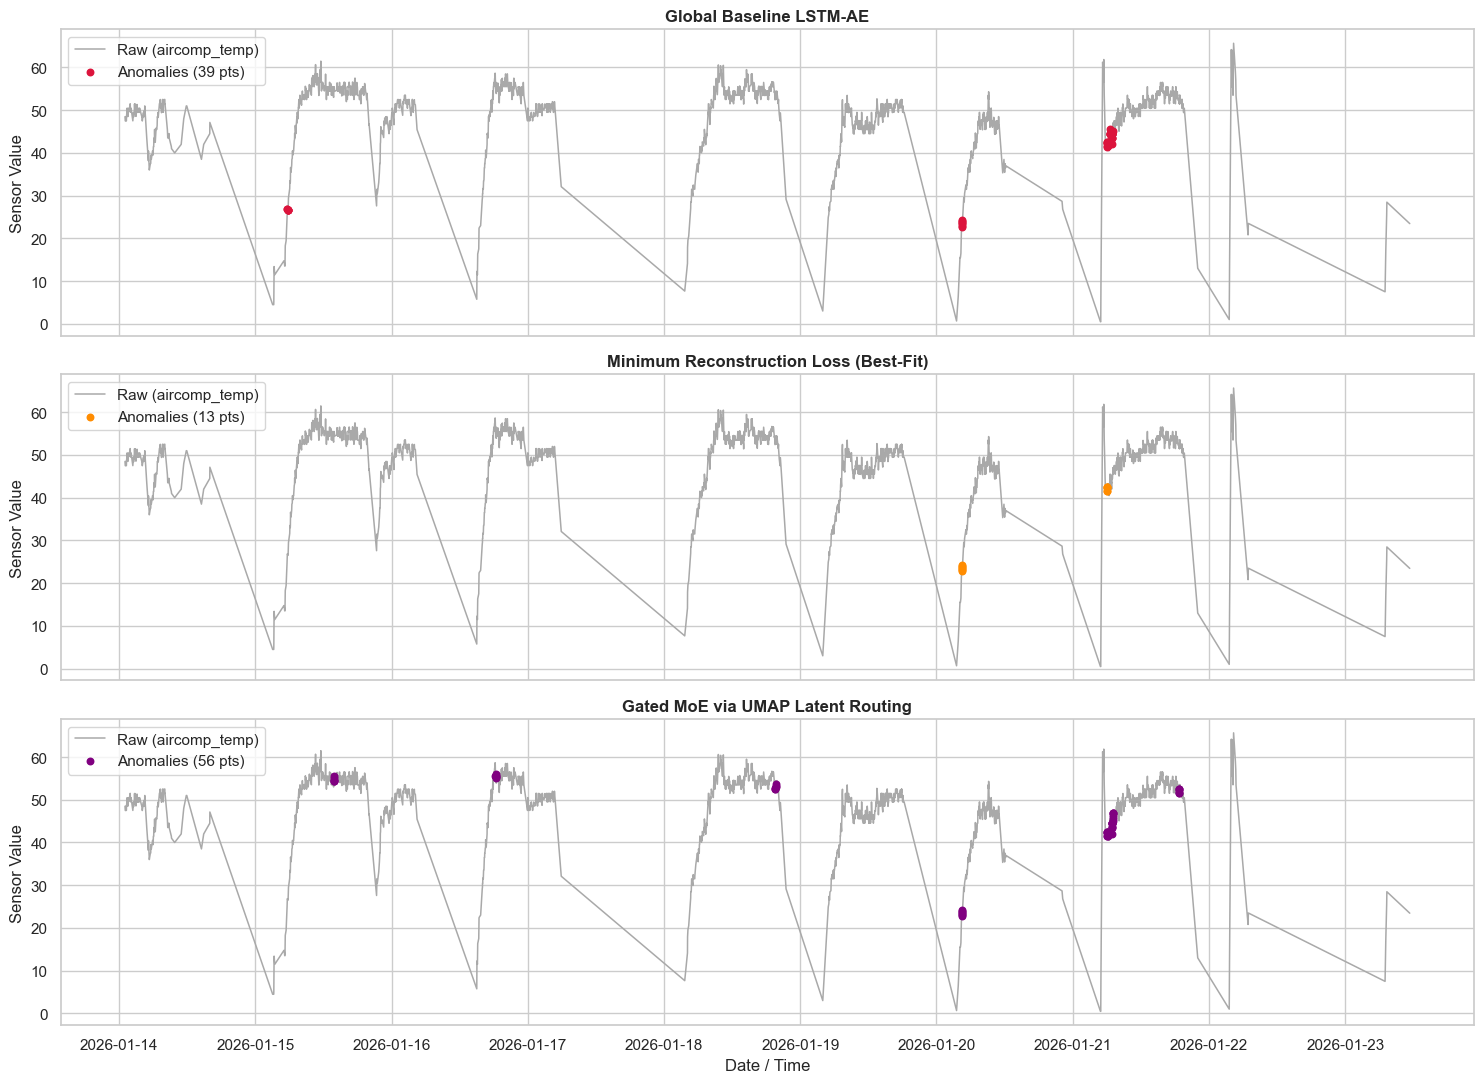

In [17]:
# =============================================================================
# 10. Visual Comparison of Strategies
# =============================================================================

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 11), sharex=True)

methods = [
    ("Global Baseline LSTM-AE", "Baseline_Sustained", "crimson", axes[0]),
    ("Minimum Reconstruction Loss (Best-Fit)", "Sol1_MinLoss_Sustained", "darkorange", axes[1]),
    ("Gated MoE via UMAP Latent Routing", "Sol2_GatedMoE_Sustained", "purple", axes[2]),
]

for title, col_name, color, ax in methods:
    ax.plot(
        test_timestamps,
        df_test[FEATURE_TO_PLOT].iloc[TIME_STEPS:],
        color="darkgray",
        linewidth=1.1,
        label=f"Raw ({FEATURE_TO_PLOT})"
    )
    
    anom_idx = comparison_df[comparison_df[col_name]].index
    if not anom_idx.empty:
        ax.scatter(
            anom_idx,
            df_test.loc[anom_idx, FEATURE_TO_PLOT],
            color=color,
            s=22,
            label=f"Anomalies ({len(anom_idx)} pts)",
            zorder=5
        )
    
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Sensor Value")
    ax.legend(loc="upper left")

axes[2].set_xlabel("Date / Time")
plt.tight_layout()
plt.show()



--- STREAMING SIMULATION: REAL-TIME OPERATING MODE TRACKER ---
[*] Initial Inferred Operating Mode: Regime 1


--- Streaming Simulation Summary ---
Total Streamed Timestamps       : 2986
Raw Stream Anomalies Flagged     : 157
Sustained Stream Anomalies (> 5m): 15


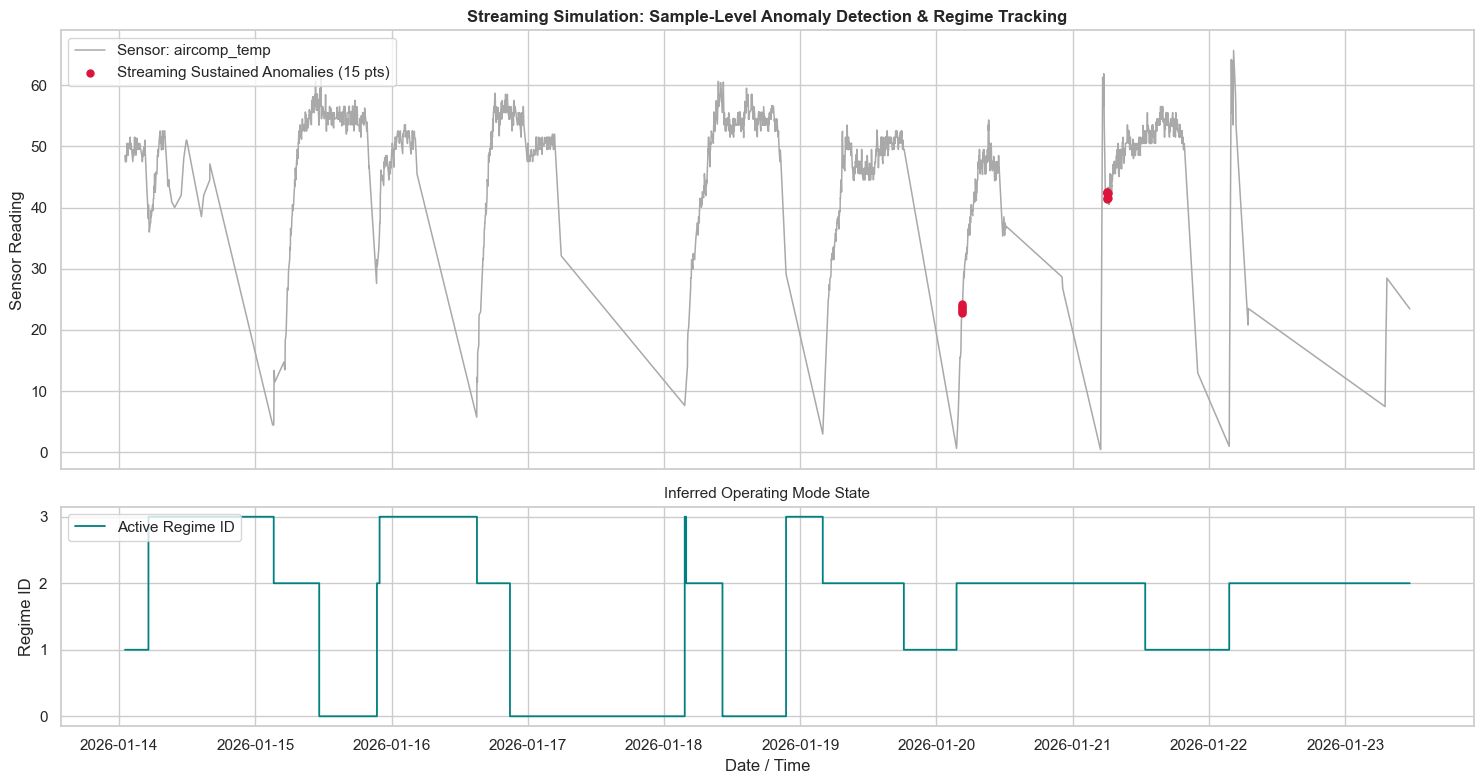

In [18]:
# =============================================================================
# 11. Streaming Simulation & Dynamic Regime-Switching Engine (Refined)
# =============================================================================

# Precompute training cluster centroids in UMAP space
unique_regimes = sorted(list(regime_models_dict.keys()))
cluster_centroids = np.array(
    [np.mean(latent_train_umap[train_cluster_labels == cid], axis=0) for cid in unique_regimes]
)
cluster_labels_arr = np.array(unique_regimes)

def get_closest_regime(latent_vec_umap: np.ndarray, max_dist: float) -> int:
    """Find nearest regime centroid in UMAP space; returns -1 if out-of-distribution."""
    closest_idx, dist = pairwise_distances_argmin_min(latent_vec_umap.reshape(1, -1), cluster_centroids)
    if dist[0] <= max_dist:
        return int(cluster_labels_arr[closest_idx[0]])
    return -1

print("\n" + "=" * 65)
print("--- STREAMING SIMULATION: REAL-TIME OPERATING MODE TRACKER ---")
print("=" * 65)

# 1. Identify Initial Operating Mode from the very first sequence
first_latent = encoder_model.predict(X_test[0:1], verbose=0)
first_latent_umap = umap_reducer.transform(first_latent)
current_mode = get_closest_regime(first_latent_umap[0], max_allowed_dist)

print(f"[*] Initial Inferred Operating Mode: Regime {current_mode}\n")

stream_log = []
total_test_sequences = len(X_test)

# 2. Sequential / Streaming Evaluation (Sample-by-Sample)
for i in range(total_test_sequences):
    sample_seq = X_test[i : i + 1]  # Shape: (1, TIME_STEPS, num_features)
    ts = df_test.index[TIME_STEPS + i]
    
    is_anomaly = False
    status = "Normal"
    sample_mae = 0.0

    # Step A: Evaluate against currently active regime model
    if current_mode in regime_models_dict:
        pred_active = regime_models_dict[current_mode].predict(sample_seq, verbose=0)
        sample_mae = float(np.mean(np.abs(pred_active - sample_seq)))
        is_normal_in_active = sample_mae <= regime_thresholds_dict[current_mode]
    else:
        is_normal_in_active = False

    # Step B: If active model rejects the sample, test other models (Regime Switch Check)
    if not is_normal_in_active:
        candidate_errors = {}
        for cid, r_model in regime_models_dict.items():
            pred_cand = r_model.predict(sample_seq, verbose=0)
            cand_mae = float(np.mean(np.abs(pred_cand - sample_seq)))
            candidate_errors[cid] = cand_mae

        best_cid = min(candidate_errors, key=candidate_errors.get)
        best_mae = candidate_errors[best_cid]

        # Check if the sample fits normally into another regime
        if best_mae <= regime_thresholds_dict[best_cid]:
            status = f"Mode Switch: {current_mode} -> {best_cid}"
            current_mode = best_cid
            sample_mae = best_mae
            is_anomaly = False
        else:
            # All regime models failed to reconstruct -> Anomaly
            status = "ANOMALY: All Regimes Exceeded Threshold"
            sample_mae = best_mae
            is_anomaly = True
            
            # Optional: Check if the latent state shifted to guide next steps
            sample_lat = encoder_model.predict(sample_seq, verbose=0)
            sample_lat_umap = umap_reducer.transform(sample_lat)
            lat_mode = get_closest_regime(sample_lat_umap[0], max_allowed_dist)
            if lat_mode != -1:
                current_mode = lat_mode  # Track latent position for recovery

    stream_log.append({
        "timestamp": ts,
        "active_mode": current_mode,
        "sample_mae": sample_mae,
        "status": status,
        "is_anomaly_raw": is_anomaly
    })

# 3. Consolidate & Apply Temporal Persistence Filter
df_stream_results = pd.DataFrame(stream_log).set_index("timestamp")
df_stream_results["is_anomaly_sustained"] = filter_sustained_anomalies(
    df_stream_results["is_anomaly_raw"], CONSECUTIVE_MINUTES
)

print("\n--- Streaming Simulation Summary ---")
print(f"Total Streamed Timestamps       : {len(df_stream_results)}")
print(f"Raw Stream Anomalies Flagged     : {df_stream_results['is_anomaly_raw'].sum()}")
print(f"Sustained Stream Anomalies (> {CONSECUTIVE_MINUTES}m): {df_stream_results['is_anomaly_sustained'].sum()}")

# 4. Stream Plot
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

ax1.plot(
    df_stream_results.index,
    df_test.loc[df_stream_results.index, FEATURE_TO_PLOT],
    color="darkgray",
    linewidth=1.1,
    label=f"Sensor: {FEATURE_TO_PLOT}",
)

stream_anoms = df_stream_results[df_stream_results["is_anomaly_sustained"]].index
if not stream_anoms.empty:
    ax1.scatter(
        stream_anoms,
        df_test.loc[stream_anoms, FEATURE_TO_PLOT],
        color="crimson",
        s=25,
        label=f"Streaming Sustained Anomalies ({len(stream_anoms)} pts)",
        zorder=5,
    )

ax1.set_title("Streaming Simulation: Sample-Level Anomaly Detection & Regime Tracking", fontsize=12, fontweight="bold")
ax1.set_ylabel("Sensor Reading")
ax1.legend(loc="upper left")

ax2.step(
    df_stream_results.index,
    df_stream_results["active_mode"],
    color="teal",
    where="post",
    linewidth=1.3,
    label="Active Regime ID",
)
ax2.set_title("Inferred Operating Mode State", fontsize=11)
ax2.set_xlabel("Date / Time")
ax2.set_ylabel("Regime ID")
ax2.set_yticks(unique_regimes)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()


In [19]:
print(df_stream_results[df_stream_results["is_anomaly_sustained"]].active_mode)

timestamp
2026-01-20 04:28:00    2
2026-01-20 04:29:00    2
2026-01-20 04:30:00    2
2026-01-20 04:31:00    2
2026-01-20 04:32:00    2
2026-01-20 04:33:00    2
2026-01-20 04:34:00    2
2026-01-21 06:02:00    2
2026-01-21 06:03:00    2
2026-01-21 06:04:00    2
2026-01-21 06:05:00    2
2026-01-21 06:06:00    2
2026-01-21 06:07:00    2
2026-01-21 06:08:00    2
2026-01-21 06:09:00    2
Name: active_mode, dtype: int64
